price_value: dtype=float64, non-null=568346, sample=[8.50e+09 5.75e+09 8.70e+09 6.50e+08 3.00e+09]
price_mode: dtype=str, non-null=573606, sample=<StringArray>
['مقطوع', 'مجانی', 'توافقی']
Length: 3, dtype: str
transformable_price: dtype=object, non-null=352894, sample=[False True]
transformable_credit: dtype=float64, non-null=352085, sample=[7.5e+08 9.5e+08 2.5e+08 1.5e+08 1.2e+09]
rent_mode: dtype=str, non-null=352994, sample=<StringArray>
['مقطوع', 'مجانی', 'توافقی']
Length: 3, dtype: str
credit_mode: dtype=str, non-null=352994, sample=<StringArray>
['مقطوع', 'مجانی', 'توافقی']
Length: 3, dtype: str
deal_type
rent    300000
Name: count, dtype: int64
Dropped constant/empty columns: ['rooms_count', 'construction_year', 'property_type', 'deal_type']
Out-of-fold R2 (log scale): 0.488
Out-of-fold MAE (log scale): 0.679


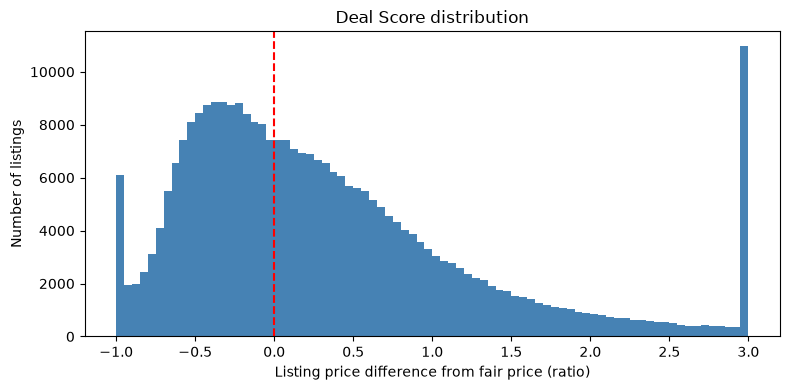

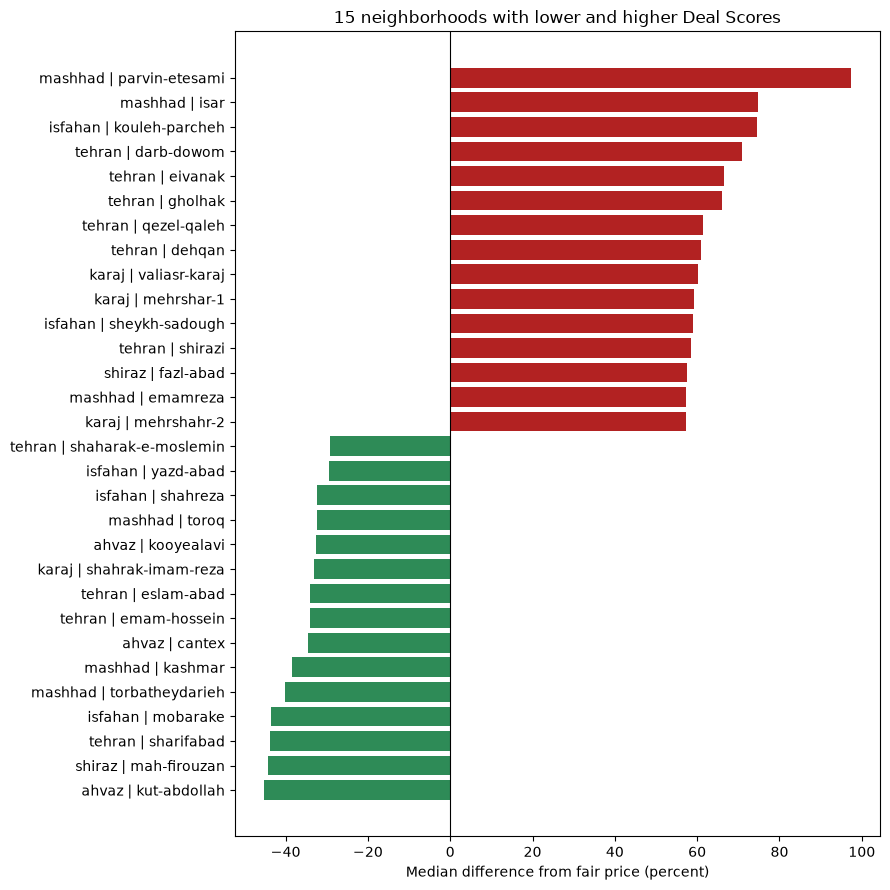

              size    median      mean
user_type                             
شخصی          9348  0.018597  0.405318
مشاور املاک  79168  0.148470  0.434503
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -0.1158      0.016     -7.216      0.000      -0.147      -0.084
C(user_type)[T.مشاور املاک]     0.1248      0.016      7.594      0.000       0.093       0.157
C(user_type)[T.مشاور املاک]    13.296334
Name: Price difference relative to reference category (percent), dtype: float64


<Figure size 700x400 with 0 Axes>

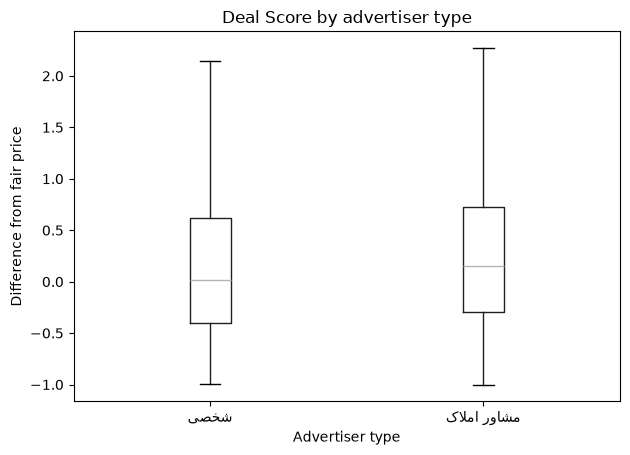

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
import statsmodels.formula.api as smf

DATA_PATH = r"C:\Users\vision\Desktop\bootcamp_p1\Divar.csv"
SAMPLE_N = 300_000
MIN_LISTINGS = 30
N_FOLDS = 5
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH, low_memory=False)

for c in [
    "price_value",
    "price_mode",
    "transformable_price",
    "transformable_credit",
    "rent_mode",
    "credit_mode"
]:
    if c in df.columns:
        print(
            f"{c}: dtype={df[c].dtype}, "
            f"non-null={df[c].notna().sum()}, "
            f"sample={df[c].dropna().unique()[:5]}"
        )

for c in [
    "price_value",
    "transformable_price",
    "transformable_credit"
]:
    df[c] = pd.to_numeric(
        df[c],
        errors="coerce"
    )

is_sale = (
    df["price_value"].notna()
    & (df["price_value"] > 0)
)

df["deal_type"] = np.where(
    is_sale,
    "sale",
    "rent"
)

df["target"] = np.where(
    is_sale,
    df["transformable_price"],
    df["transformable_credit"]
).astype(float)

df = df[
    df["target"].notna()
    & (df["target"] > 0)
].copy()

lo = df.groupby(
    "deal_type"
)["target"].transform(
    lambda s: s.quantile(0.005)
)

hi = df.groupby(
    "deal_type"
)["target"].transform(
    lambda s: s.quantile(0.995)
)

df = df[
    (df["target"] >= lo)
    & (df["target"] <= hi)
].copy()

if SAMPLE_N and len(df) > SAMPLE_N:
    df = df.sample(
        SAMPLE_N,
        random_state=RANDOM_STATE
    )

df = df.reset_index(drop=True)
df["log_target"] = np.log(df["target"])

print(
    df["deal_type"].value_counts()
)

num_cols = [
    "building_size",
    "land_size",
    "rooms_count",
    "construction_year",
    "floor",
    "total_floors_count",
    "unit_per_floor"
]

bool_cols = [
    "has_balcony",
    "has_elevator",
    "has_warehouse",
    "has_parking",
    "has_pool",
    "has_jacuzzi",
    "has_sauna",
    "has_barbecue",
    "is_rebuilt"
]

cat_cols = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "deed_type",
    "property_type",
    "deal_type"
]

num_cols = [
    c for c in num_cols
    if c in df.columns
]

bool_cols = [
    c for c in bool_cols
    if c in df.columns
]

cat_cols = [
    c for c in cat_cols
    if c in df.columns
]

X = pd.DataFrame(
    index=df.index
)

for c in num_cols:
    X[c] = pd.to_numeric(
        df[c],
        errors="coerce"
    )

for c in bool_cols:
    X[c] = pd.to_numeric(
        df[c].replace({
            True: 1,
            False: 0,
            "True": 1,
            "False": 0,
            "true": 1,
            "false": 0
        }),
        errors="coerce"
    )

for c in cat_cols:
    s = (
        df[c]
        .astype("string")
        .fillna("missing")
    )

    top = (
        s.value_counts()
        .nlargest(100)
        .index
    )

    X[c] = (
        s.where(
            s.isin(top),
            "other"
        )
        .astype("category")
    )

const_cols = [
    c for c in X.columns
    if X[c].nunique(dropna=True) < 2
]

print(
    "Dropped constant/empty columns:",
    const_cols
)

X = X.drop(
    columns=const_cols
)

y = df["log_target"]

model = HistGradientBoostingRegressor(
    categorical_features="from_dtype",
    max_iter=300,
    learning_rate=0.08,
    random_state=RANDOM_STATE
)

cv = KFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

df["pred_log"] = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    n_jobs=1
)

print(
    f"Out-of-fold R2 (log scale): "
    f"{r2_score(y, df['pred_log']):.3f}"
)

print(
    f"Out-of-fold MAE (log scale): "
    f"{mean_absolute_error(y, df['pred_log']):.3f}"
)

df["log_ratio"] = (
    df["log_target"]
    - df["pred_log"]
)

df["pct_dev"] = (
    np.exp(df["log_ratio"])
    - 1
)

plt.figure(
    figsize=(8, 4)
)

plt.hist(
    df["pct_dev"].clip(-1, 3),
    bins=80,
    color="steelblue"
)

plt.axvline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel(
    "Listing price difference from fair price (ratio)"
)

plt.ylabel(
    "Number of listings"
)

plt.title(
    "Deal Score distribution"
)

plt.tight_layout()
plt.show()

df["loc"] = (
    df["city_slug"].astype(str)
    + " | "
    + df["neighborhood_slug"].astype(str)
)

hood = (
    df.groupby("loc")
    .agg(
        n=("pct_dev", "size"),
        median_dev=("pct_dev", "median"),
        mean_log_ratio=("log_ratio", "mean")
    )
    .query("n >= @MIN_LISTINGS")
    .sort_values("median_dev")
)

top = pd.concat([
    hood.head(15),
    hood.tail(15)
])

plt.figure(
    figsize=(9, 9)
)

colors = [
    "seagreen" if v < 0 else "firebrick"
    for v in top["median_dev"]
]

plt.barh(
    top.index,
    top["median_dev"] * 100,
    color=colors
)

plt.axvline(
    0,
    color="black",
    linewidth=0.8
)

plt.xlabel(
    "Median difference from fair price (percent)"
)

plt.title(
    "15 neighborhoods with lower and higher Deal Scores"
)

plt.tight_layout()
plt.show()

hood.to_csv(
    "neighborhood_deal_score.csv"
)

print(
    df.groupby("user_type")["pct_dev"].agg([
        "size",
        "median",
        "mean"
    ])
)

d = df[
    df["user_type"].notna()
].copy()

d["lr_within"] = (
    d["log_ratio"]
    - d.groupby("loc")["log_ratio"].transform("mean")
)

res = smf.ols(
    "lr_within ~ C(user_type)",
    data=d
).fit(
    cov_type="HC3"
)

print(
    res.summary().tables[1]
)

coefs = res.params.drop(
    "Intercept"
)

print(
    (
        np.exp(coefs) - 1
    ).rename(
        "Price difference relative to reference category (percent)"
    ) * 100
)

plt.figure(
    figsize=(7, 4)
)

d.boxplot(
    column="pct_dev",
    by="user_type",
    showfliers=False,
    grid=False
)

plt.suptitle("")

plt.title(
    "Deal Score by advertiser type"
)

plt.xlabel(
    "Advertiser type"
)

plt.ylabel(
    "Difference from fair price"
)

plt.tight_layout()
plt.show()